In [ ]:

import numpy as np
import pandas as pd
import sys

np.set_printoptions(precision = 10, linewidth = np.inf)
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('max_colwidth', None)
pd.options.display.float_format = '{:,.10f}'.format

sys.path.append('/content')
import Regression

df = pd.read_csv('/content/unemployment_model_input.csv')

print("=== Dataset Loaded ===")
print(df.head())
print("\n=== Summary ===")
print(df.describe(include='all'))




=== Dataset Loaded ===
         Date               ICSA                 CCSA       UNRATE           JTSJOL       CPIAUCSL     FEDFUNDS             PAYEMS      log_ICSA      log_CCSA          ICSA_lag1            CCSA_lag1        PAYEMS_lag1      JTSJOL_lag1          ICSA_lag3      JTSJOL_lag3      ICSA_pct    PAYEMS_pct    JTSJOL_pct           ICSA_ma3             CCSA_ma3   UNRATE_ma3
0  2000-12-01 387,200.0000000000 2,585,400.0000000000 4.3000000000 4,762.0000000000 176.1000000000 5.3100000000 132,751.0000000000 12.8666966344 14.7653907928 371,250.0000000000 2,486,500.0000000000 132,788.0000000000 5,097.0000000000 346,000.0000000000 5,088.0000000000  0.0429629630 -0.0002786396 -0.0657249362 366,150.0000000000 2,489,216.6666666665 4.2333333333
1  2001-01-01 396,750.0000000000 2,697,250.0000000000 4.4000000000 4,615.0000000000 176.4000000000 4.8000000000 132,457.0000000000 12.8910616384 14.8077432934 387,200.0000000000 2,585,400.0000000000 132,751.0000000000 4,762.0000000000 340,000.00

In [ ]:

target_name = 'UNRATE'
y = df[target_name]

# Remove date column
drop_cols = ['DATE']


candidate_predictors = [
    'ICSA','CCSA','JTSJOL','CPIAUCSL','FEDFUNDS','PAYEMS',
    'log_ICSA','log_CCSA','ICSA_lag1','CCSA_lag1','PAYEMS_lag1',
    'JTSJOL_lag1','ICSA_lag3','JTSJOL_lag3','ICSA_pct','PAYEMS_pct',
    'JTSJOL_pct','ICSA_ma3','CCSA_ma3','UNRATE_ma3'
]

print("\n=== Candidate Predictors ===")
print(candidate_predictors)

# Build modeling dataset
model_df = df[candidate_predictors + [target_name]].dropna().reset_index(drop=True)

print("\n=== Final Modeling Dataset Shape ===")
print(model_df.shape)



=== Candidate Predictors ===
['ICSA', 'CCSA', 'JTSJOL', 'CPIAUCSL', 'FEDFUNDS', 'PAYEMS', 'log_ICSA', 'log_CCSA', 'ICSA_lag1', 'CCSA_lag1', 'PAYEMS_lag1', 'JTSJOL_lag1', 'ICSA_lag3', 'JTSJOL_lag3', 'ICSA_pct', 'PAYEMS_pct', 'JTSJOL_pct', 'ICSA_ma3', 'CCSA_ma3', 'UNRATE_ma3']

=== Final Modeling Dataset Shape ===
(294, 21)


In [ ]:
#forward selection
from scipy.stats import f

# Set up candidates
candidate_name = candidate_predictors.copy()
cat_name = []

train_data = model_df.copy()

n_sample = train_data.shape[0]
y = train_data[target_name]

enter_threshold = 0.05
step_diary = []

var_in_model = ['Intercept']  # intercept only

X0 = train_data[[]].copy()
X0.insert(0, 'Intercept', 1.0)

result_list = Regression.LinearRegression(X0, y)
m0 = len(result_list[5])
SSE0 = result_list[2] * result_list[3]

step_diary.append([0, 'Intercept', SSE0, m0] + 4 * [np.nan])

# Forward selection loop
for iStep in range(len(candidate_name)):
    FTest = []

    for pred in candidate_name:
        X = train_data[[pred]].copy()
        X = X0.join(X)

        result_list = Regression.LinearRegression(X, y)
        m1 = len(result_list[5])
        SSE1 = result_list[2] * result_list[3]

        df_numer = m1 - m0
        df_denom = n_sample - m1

        if df_numer > 0 and df_denom > 0:
            FStat = ((SSE0 - SSE1) / df_numer) / (SSE1 / df_denom)
            FSig = f.sf(FStat, df_numer, df_denom)
            FTest.append([pred, SSE1, m1, FStat, df_numer, df_denom, FSig])

    # print each step’s F-tests
    print(f"\n===== F Test Results for Step {iStep} =====")
    for row in FTest:
        print(row)

    # Pick best variable
    FTest.sort(key=lambda s: s[6])
    best = FTest[0]

    if best[6] <= enter_threshold:
        enter_var = best[0]
        step_diary.append([iStep+1] + best)

        SSE0 = best[1]
        m0 = best[2]

        X0 = X0.join(train_data[[enter_var]])

        var_in_model.append(enter_var)
        candidate_name.remove(enter_var)
    else:
        print("\nStopping: No variable meets entry threshold.")
        break

forward_summary = pd.DataFrame(step_diary, columns=[
    'Step', 'Variable', 'SSE', 'Params', 'F Stat', 'DF1', 'DF2', 'p-value'
])

print("\n===== Forward Selection Summary =====")
print(forward_summary)

print("\n=== VARIABLES SELECTED BY FORWARD SELECTION ===")
print(var_in_model)



===== F Test Results for Step 0 =====
['ICSA', np.float64(787.5232777071915), 2, np.float64(126.08200097104803), 1, 292, np.float64(1.4707736596865158e-24)]
['CCSA', np.float64(544.88722968405), 2, np.float64(312.25220085633947), 1, 292, np.float64(4.999144173135067e-48)]
['JTSJOL', np.float64(716.9223207332318), 2, np.float64(167.25381067555753), 1, 292, np.float64(1.4854746711996277e-30)]
['CPIAUCSL', np.float64(1009.6522325147826), 2, np.float64(34.10169833926489), 1, 292, np.float64(1.392103190500377e-08)]
['FEDFUNDS', np.float64(735.0465702563642), 2, np.float64(155.92986060769965), 1, 292, np.float64(5.814701697851589e-29)]
['PAYEMS', np.float64(628.8781566271977), 2, np.float64(231.55023669598006), 1, 292, np.float64(6.639963059753667e-39)]
['log_ICSA', np.float64(486.480540229025), 2, np.float64(384.79851613406197), 1, 292, np.float64(3.0846093768483772e-55)]
['log_CCSA', np.float64(302.18870154844456), 2, np.float64(797.5487027410198), 1, 292, np.float64(1.753751541489236e-85

In [ ]:
#Linear Regression Model
final_vars = [
    'UNRATE_ma3', 'PAYEMS_pct', 'ICSA_lag1', 'CCSA_ma3',
    'CCSA', 'ICSA_ma3', 'log_ICSA', 'PAYEMS',
    'ICSA_lag3', 'PAYEMS_lag1'
]

# Build X matrix
X_final = model_df[final_vars].copy()
X_final.insert(0, 'Intercept', 1.0)

# Run regression
final_result = Regression.LinearRegression(X_final, y)

# coefficient table
coef_table = final_result[0]
beta = coef_table["Estimate"].values

print("=== Final Model Coefficients ===")
for name, coef in zip(X_final.columns, beta):
    print(f"{name:15s}: {coef:.6f}")

sigma2 = final_result[2]
residual_df = final_result[3]

print("\nResidual Variance:", sigma2)
print("Residual DF:", residual_df)


=== Final Model Coefficients ===
Intercept      : -1.863345
UNRATE_ma3     : 0.994949
PAYEMS_pct     : -136.910611
ICSA_lag1      : 0.000001
CCSA_ma3       : -0.000000
CCSA           : 0.000000
ICSA_ma3       : -0.000000
log_ICSA       : 0.130983
PAYEMS         : 0.000696
ICSA_lag3      : -0.000000
PAYEMS_lag1    : -0.000694

Residual Variance: 0.00928395873713952
Residual DF: 283


In [ ]:
#December 2025 U-3 Unemployment Rate

last_row = model_df.iloc[-1]

print("\n=== Most Recent Month Used For Prediction ===")
print(last_row)

# Build X_new using exactly the same final variables
X_new = pd.DataFrame([{
    'Intercept': 1.0,
    'UNRATE_ma3': last_row['UNRATE_ma3'],
    'PAYEMS_pct': last_row['PAYEMS_pct'],
    'ICSA_lag1': last_row['ICSA_lag1'],
    'CCSA_ma3': last_row['CCSA_ma3'],
    'CCSA': last_row['CCSA'],
    'ICSA_ma3': last_row['ICSA_ma3'],
    'log_ICSA': last_row['log_ICSA'],
    'PAYEMS': last_row['PAYEMS'],
    'ICSA_lag3': last_row['ICSA_lag3'],
    'PAYEMS_lag1': last_row['PAYEMS_lag1']
}])


beta = coef_table["Estimate"].values
prediction = float(X_new.values @ beta)

print("\n=== FINAL PREDICTION FOR DECEMBER 2025 UNRATE ===")
print(prediction)



=== Most Recent Month Used For Prediction ===
ICSA            230,000.0000000000
CCSA          1,942,600.0000000000
JTSJOL            7,227.0000000000
CPIAUCSL            323.3640000000
FEDFUNDS              4.3300000000
PAYEMS          159,540.0000000000
log_ICSA             12.3458345879
log_CCSA             14.4795378400
ICSA_lag1       221,250.0000000000
CCSA_lag1     1,950,250.0000000000
PAYEMS_lag1     159,518.0000000000
JTSJOL_lag1       7,208.0000000000
ICSA_lag3       234,000.0000000000
JTSJOL_lag3       7,712.0000000000
ICSA_pct              0.0395480226
PAYEMS_pct            0.0001379155
JTSJOL_pct            0.0026359600
ICSA_ma3        230,833.3333333333
CCSA_ma3      1,948,533.3333333333
UNRATE_ma3            4.2000000000
UNRATE                4.3000000000
Name: 293, dtype: float64

=== FINAL PREDICTION FOR DECEMBER 2025 UNRATE ===
4.225594474100689


/tmp/ipython-input-2551626390.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prediction = float(X_new.values @ beta)


## Model Evauation


In [ ]:
sigma2 = final_result[2]
residual_df = final_result[3]

print("\nResidual Variance:", f"{sigma2:.4f}")
print("Residual DF:", residual_df)


Residual Variance: 0.0093
Residual DF: 283


Measures how much the predictions differ from actual values. A small number like 0.0093 means our predictions are very close to the real data.

In [ ]:
#Mean absolute Error
y_pred = X_final.values @ beta

mae = np.mean(np.abs(y - y_pred))
print("\n=== Mean Absolute Error (MAE) ===")
print(f"{mae:.4f}")


=== Mean Absolute Error (MAE) ===
0.0711


On average, our predicted U-3 rate is off by about 0.071 percentage points, which is very small.

In [ ]:
#RMSE
y_pred = X_final.values @ beta

rmse = np.sqrt(np.mean((y - y_pred) ** 2))
print("\n=== Root Mean Squared Error (RMSE) ===")
print(f"{rmse:.4f}")


=== Root Mean Squared Error (RMSE) ===
0.0945


Similar to MAE but gives more weight to larger errors. A low value shows that the model rarely makes big mistakes.

In [ ]:
#R squared
y_pred = X_final.values @ beta

ss_total = np.sum((y - np.mean(y))**2)
ss_residual = np.sum((y - y_pred)**2)
r_squared = 1 - (ss_residual / ss_total)

print("\n=== R-squared ===")
print(f"{r_squared:.4f}")


=== R-squared ===
0.9977


In [ ]:
#Adjusted R squared
n = len(y)
p = X_final.shape[1] - 1
adjusted_r2 = 1 - (1 - r_squared) * ((n - 1) / (n - p - 1))

print("\n=== Adjusted R-squared ===")
print(f"{adjusted_r2:.4f}")


=== Adjusted R-squared ===
0.9976


About 99.77% of the changes in U-3 unemployment are explained by our model. This shows an excellent fit with the data.

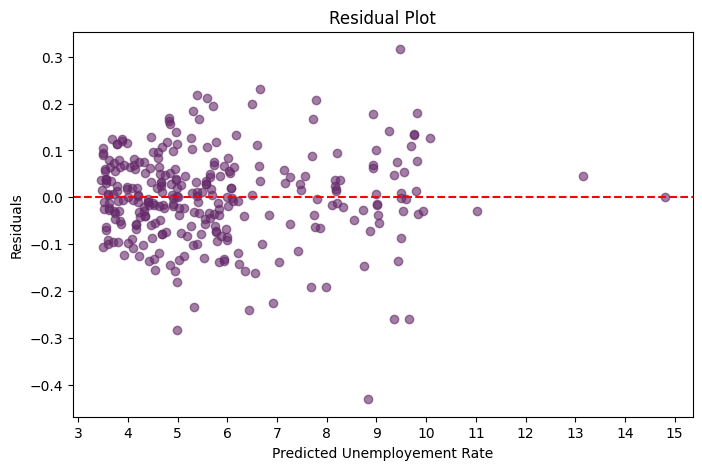

In [ ]:
import matplotlib.pyplot as plt

y_pred = X_final.values @ beta

residuals = y - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, color='#642969', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Unemployement Rate")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.xticks(np.arange(3, int(np.ceil(max(y_pred))) + 1, 1))
plt.show()

The residuals are mostly scattered around zero, showing that the model fits the data well. The spread of residuals is fairly consistent, with just a little more variation at higher predicted values. A few points are farther from zero, indicating occasional larger errors. Overall, the residuals are small, showing that the model predicts the unemployment rate very accurately.